## Bridging Creation to Reality: The Connections between "Umamusume: Pretty Derby" and Japanese Horse Racing
Rachel Tsai

### 1. Project Questions and Goals

Released in 2021, Umamusume: Pretty Derby (hereafter referred to as "Umamusume") is a mobile game featuring characters heavily inspired by real-life Japanese racehorses. It has commonly been praised for its adaptation of Japanese horse racing in both its story content and visual character design, on a level not often seen in other media based around anthropomorphization. This project seeks to analyze this insipration by investigating possible connections between the arbitrary values assigned to characters in the game and the true demographic and race statistics of the corresponding racehorses, to formally discern how Umamusume takes inspiration from Japanese horse racing and adapts them into its own distinct identity.

<figure>
    <img src="https://upload.wikimedia.org/wikipedia/en/3/31/Umamusume_Pretty_Derby_game_cover.jpg" height = "200" style="display: block; margin: auto;">
    <figcaption style="text-align: center;" >Game cover of Umamusume: Pretty Derby on Steam (adapted from Wikipedia)</figcatption>
</figure>

The questions to be investigated in this analysis can be grouped into 2 main research goals. First, the demographics of horses represented in Umamusume will be surveyed, providing possible insight into the selection process and possible bias. Demographics that will be surveyed in this part will be foaled year (birth year) and training facility. Then, Umamusume and racehorse data will be directly compared to explore correlations between variables the two datasets. The first pair of variables that will be compared are racehorse weight and Umamusume character height, which can be said to be similar measures of size in their respective datasets. Finally, the win rates of racehorses will be used as a metric of strength and compared with a similar metric of gameplay strength in Umamusume character data, the prescence of speed and power growth attributes.

### 2. Data Description

The dataset from Umamusume is extracted from the master.mdb file from the internal files of the 2.24.1 release of Umamusume. As the orignal mdb file has a large amount of tables and information, I have also provided a cleaned-up version containing only the tables utilized in this analysis for code tracing purposes. Each row represents one character, and variables of interest in this dataset are Japanse name, Height, Speed growth, and Power growth.

This database contains entries for both original and alternate version of characters. For the purposes of this analysis, only original forms will be considered, and alternate versions forms will be filtered out. Aftering filtering, the database to be used in analysis contains 126 rows in total, corresponding to 126 unique characters. An additional boolean column will also be created to facilitate grouping of characters based on if they have speed and power growth attributes.

For racehorse data, the database hosted on the website https://en.netkeiba.com will be utilized via web scraping using BeautifulSoup. An extracted local version of the data used in this project will be provided as a .csv file. Each row represents one racehorse, and variables of interest in this dataset are Japanese name, English name, Foaled date, Training facility, Wins, Starts, and Horse weight.

Only data pertaining to the characters denoted in the Umamusume database will be extracted, so this database will also contain 126 rows in total. As netkeiba is fairly comprehensive and well-maintained, it is safe to assume that every character in the Umamusume database will have a corresponding horse entry on the website. Scraped data will be converted into proper object types (eg. datetime for Foaled date). To summarize race records in one variable, win rate as a percentage will be calculated from Wins and Starts, and stored in a new float column. Because there is no single weight value on the site, weight values from all races will be scraped from the corresponding records page of the horse, averaged and stored in a new float column. Unfortunately, this data is not available for horses foaled before 1984 due to the lack of available official race records from that time period. As these missing values only affect one of the queries done in this report, these values will be left missing and the corresponding horses will be excluded from the affected query.

<figure>
    <img src="https://cdn.netkeiba.com/img.en/info/photo_img.html?type=info&id=1&v=MjAyNC0wMy0yMiAyMTo1OToxNA==" height="200" style="display: block; margin: auto;">
    <figcaption style="text-align: center;" >Screenshot of the English version of netkeiba.com (adapted from netkeiba.com)</figcatption>
</figure>


The schemas of the databases used in the analysis are defined below.

In [16]:
import functions as pj
import sqlite_helpers as sh
import matplotlib.pyplot as plt
import numpy as np

In [17]:
# creating sqlite database file and connection to it
sh.create_database('project_db.sqlite')
conn = sh.connect('project_db.sqlite')

# defining table schemas and creating tables
uma_table = '''CREATE TABLE umamusume (
    umamusume_id INT PRIMARY KEY,
    japanese_name TEXT,
    height INT,
    speed_growth INT,
    power_growth INT,
    has_speed_and_power INT,
    UNIQUE (japanese_name)
);
'''
netkeiba_table = '''CREATE TABLE netkeiba (
    netkeiba_id TEXT PRIMARY KEY,
    japanese_name TEXT,
    english_name TEXT,
    foaled_date DATE,
    trained_at TEXT,
    average_race_weight FLOAT,
    wins INT,
    starts INT,
    win_percent FLOAT,
    UNIQUE (japanese_name, english_name)
    FOREIGN KEY (japanese_name) REFERENCES umamusume(japanese_name)
);
'''

sh.add_table(conn, uma_table)
sh.add_table(conn, netkeiba_table)

OperationalError: table umamusume already exists

### 3. Analysis, Results and Interpretation

In [ ]:
# Extracting data from master.mdb, cleaning it and storing it in the umamusume table
# For reproduction purposes, please place the 'master.mdb' file in the same folder as this file (alternatively if this is not possible, please call pj.get_uma using the following arguement: 'sqlite:///[absolute path to master.mdb]')
uma_df = pj.get_uma('sqlite:///Data/master.mdb')
pj.clean_uma(uma_df)
uma_df.to_sql('umamusume', conn, if_exists='append', index=False)
uma_df.head()

,umamusume_id,japanese_name,height,speed_growth,power_growth,has_speed_and_power
0,1001,スペシャルウィーク,158,0,0,False
3,1002,サイレンススズカ,161,20,0,False
5,1003,トウカイテイオー,150,20,0,False
8,1004,マルゼンスキー,164,10,0,False
11,1005,フジキセキ,168,0,20,False


In [ ]:
# Scraping data from netkeiba.com, cleaning it and storing it in the netkeiba table
# This step will take a while to run due to having to scrape a large number of webpages (~5 minutes)
netkeiba_df = pj.build_netkeiba(uma_df[pj.JP_NAME])
pj.clean_netkeiba(netkeiba_df)
netkeiba_df.to_sql('netkeiba', conn, if_exists='append', index=False)
netkeiba_df.head()

,netkeiba_id,japanese_name,english_name,foaled_date,trained_at,wins,starts,average_race_weight,win_percent
0,1995103211,スペシャルウィーク,Special Week,1995-05-02,Ritto,10,17,471.882353,58.823529
1,1994103997,サイレンススズカ,Silence Suzuka,1994-05-01,Ritto,9,16,438.400000,56.250000
2,1988101025,トウカイテイオー,Tokai Teio,1988-04-20,Ritto,9,12,466.000000,75.000000
3,000a0003bd,マルゼンスキー,Maruzensky,1974-05-19,NaN,8,8,NaN,100.000000
4,1992109618,フジキセキ,Fuji Kiseki,1992-04-15,Ritto,4,4,489.500000,100.000000


First, to gain an understanding of the distribution and representation of horses in Umamusume, two separate queries on demographic variables (Foaled year, Training center) will be performed on the entire population of interest.

In [ ]:
foaled_dates_query = '''SELECT english_name, strftime('%Y', foaled_date) AS foaled_year
FROM netkeiba
ORDER BY foaled_year DESC;
''' 
foaled_dates = sh.run_sql(conn, foaled_dates_query)
print(foaled_dates)

       english_name foaled_year
0      Gran Alegria        2016
1    Loves Only You        2016
2    Chrono Genesis        2016
3        Almond Eye        2015
4            Kiseki        2014
..              ...         ...
121  Sirius Symboli        1982
122  Symboli Rudolf        1981
123       Mr. C. B.        1980
124   Katsuragi Ace        1980
125      Maruzensky        1974

[126 rows x 2 columns]


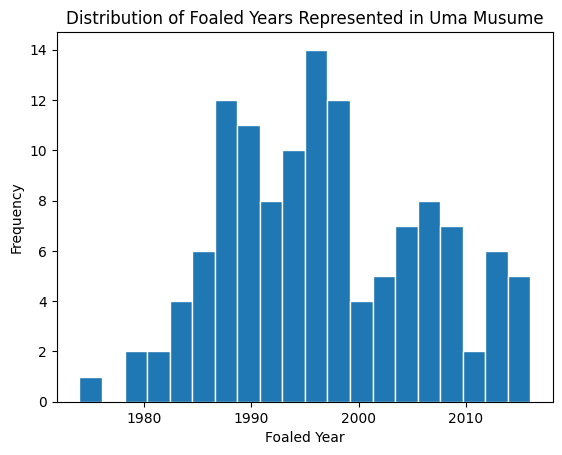

In [ ]:
foaled_dates['foaled_year'].astype('int32').plot(kind='hist', bins=20, edgecolor='white', xlabel='Foaled Year', title='Distribution of Foaled Years Represented in Uma Musume')
plt.show()

The range of foaled dates represented span from 1974 to 2016, encompassing a 42 year timespan in total. As observed in the histogram, there are a few notable peaks at around 1987 and 1995, and a modest peak at around 2006. These peaks correspond with notable time periods where horse racing was popular in Japan, an example being the so-called Golden Generation foaled in 1995. Conversely, dips in the histogram such as the one at 2011 may be associated with less popular eras, though this correlation is a bit weaker. Additionally, the lack of representation in these years may be due to Umamusume developers being unable to obtain the licenses to use the popular horses of those years. 

Notably there are no large gaps in coverage, barring the small gap right after the single outlier at 1974, Maruzensky. The fact that there is only a single example of such an isolated character era-wise brings to light one of the design philosophies of Umamusume. Because in-game stories and groupings are based off of real stories in horse racing, almost every character has at least one contemporary from the same era to interact with. There is some solid evidence that this case with Maruzensky is not a oversight; the racehorse Maruzenky was known for being very dominant during his career, to the point where there may be no "rivals" for Umamusume to adapt into the game in the first place. 

In [ ]:
training_query = '''SELECT trained_at, COUNT(*)
FROM netkeiba
GROUP BY trained_at;
'''
none_query = '''SELECT english_name, trained_at
FROM netkeiba
WHERE trained_at IS NULL;'''

training = sh.run_sql(conn, training_query)
print(training.head())
sh.run_sql(conn, none_query)

  trained_at  COUNT(*)
0       None         1
1       Miho        33
2        NAR         3
3      Ritto        89


,english_name,trained_at
0,Maruzensky,None


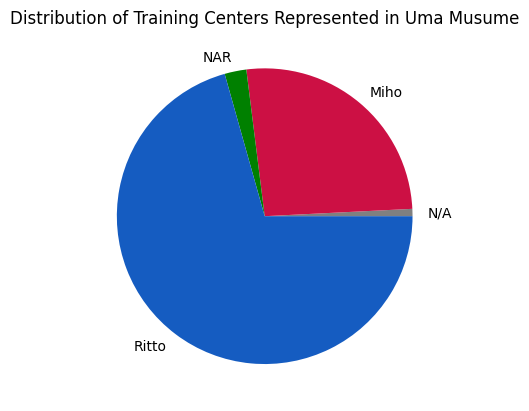

In [ ]:
labels = training['trained_at'].fillna('N/A') #creates label for None group
plt.pie(training['COUNT(*)'], labels=labels,
        colors=['grey', '#cc1044', 'green', '#155cc1'])
plt.title('Distribution of Training Centers Represented in Uma Musume')
plt.show()

There is a clear dominating class in the distribution, with Ritto making up almost 3/4 of the dataset. Miho makes up the majority of the rest of the entries, with NAR taking up a very small portion of the distribution, with only 3 entries. This distribution can be interpreted in two ways. Firstly, these proportions could be interpreted as representative of the training center proportions of all racehorses trained, in other terms the proportions of the full dataset hosted on netkeiba. 

However it is important to note that the population of interest in this analysis is biased due to the fact that the horses that are represented in Umamusume are chosen because they are well-known, which in most cases is a product of a successful career. With this context, the shown distribution may be more reflective of the success of the different training centers. Under this interpretation, a conclusion can be drawn that horses from Ritto are overall the most successful and famous. This intepretation would also explain why there are so few NAR entries; horse racing in Japan is dominated by the central races organized by the JRA organization (who runs both Ritto and Miho traning centers), with regional racing run by the NAR organization seen as more niche. In addition the training facilities run by JRA are more expansive and have better funding, which translates to central horses consistently having an edge over their local competitors at the racetrack. 

The single outlier with no training center data is once again Maruzensky. This may be due to the lack of standardized infokeeping at the time of Maruzensky's career, or the fact that the horse predates the 2 training center system used by JRA today (Miho training center was established in 1978, a year after Maruzenky retired).

Next, specific variables from both the Umamusume and netkeiba datasets will be called and compared for evidence of possible correlations.

As mentioned in the Data Description section, horses foaled before 1984 will be excluded from this query as there is no race weight information available for them.

In [ ]:
height_weight_query= '''SELECT english_name, height, average_race_weight
FROM umamusume
JOIN netkeiba
ON umamusume.japanese_name = netkeiba.japanese_name
WHERE average_race_weight NOT NULL
ORDER BY height DESC;
'''

# helper query to highlight outliers discussed in analysis
outlier_query = '''SELECT height, average_race_weight
FROM umamusume
JOIN netkeiba
ON umamusume.japanese_name = netkeiba.japanese_name
WHERE english_name IN ('Hishi Akebono', 'Nishino Flower', 'Zenno Rob Roy');
'''

height_weight = sh.run_sql(conn, height_weight_query)
outliers = sh.run_sql(conn, outlier_query)
print(height_weight)

       english_name  height  average_race_weight
0     Hishi Akebono     180           553.100000
1     Taiki Shuttle     172           507.166667
2     Biwa Hayahide     171           478.250000
3          Fenomeno     171           494.777778
4         Gold Ship     170           503.555556
..              ...     ...                  ...
115   Zenno Rob Roy     140           499.368421
116      Haru Urara     140           405.530973
117       Inari One     139           448.880000
118     Sweep Tosho     139           459.250000
119  Nishino Flower     135           429.500000

[120 rows x 3 columns]


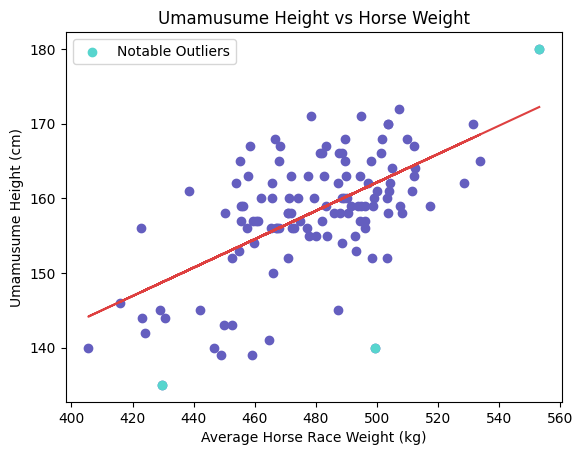

In [ ]:
x = height_weight['average_race_weight']
y = height_weight['height']
slope, intercept = np.polyfit(x, y, 1)
line = slope * x + intercept
out_x = outliers['average_race_weight']
out_y = outliers['height']

plt.scatter(x, y, color="#645EBF")
plt.scatter(out_x, out_y, color="#57D5CE", label='Notable Outliers')
plt.legend()
plt.title('Umamusume Height vs Horse Weight')
plt.ylabel('Umamusume Height (cm)')
plt.xlabel('Average Horse Race Weight (kg)')
plt.plot(x, line, color="#DE4040")
plt.show()

Looking at the scatter plot, height entries are fairly spread out but still follow a slight linear trend upwards as average race weight increases, giving evidence that a horse's race weight is considered to a degree when deciding a character's height. 

In evaluating evidence of a linear relationship, it is imperative to address outliers in the dataset, as they can disproportionally skew the line of best fit and interpretations of the relationship as a whole. For easy visualization, the outliers discussed below are highlighted in blue in the plot. The most visually notable outlier here is the entry closest to the top-right corner representing Hishi Akebono, who has the highest weight and height values by a large margin. On the other end of the spectrum is Nishino Flower, with a relatively small weight value and the lowest height value of the dataset. Both of these outliers may have skewed the calculated line of best fit in a way that does not reflect the relationship between the two variables of interest in the majority of entries.

Interestingly, there are also outliers that go against the linear trend seen in the data. One such outlier is Zenno Rob Roy, who has a moderately high weight value (499 kg) but a low height value (140 cm). Entries such as these show evidence that there is nuance when it comes to determining umamusume height. Especially light or heavy horses are given more extreme height values to emphasize those attributes, while for horses with more average weight values other factors such as personality or visual design play a larger role in determining character height.

For the next query, Umamusume characters with both speed and power growth attributes will be referred to as "Meta umamusume", and all other characters as "Normal umamusume".

In [ ]:
growth_win_q = '''SELECT win_percent
FROM umamusume
JOIN netkeiba
ON umamusume.japanese_name = netkeiba.japanese_name
WHERE has_speed_and_power = ?;
'''

growth_win_pct = sh.run_sql(conn, growth_win_q, (True,))
no_growth_win_pct = sh.run_sql(conn, growth_win_q, (False, ))

print(f'Meta Umamusume: {growth_win_pct.mean()}')
print(f'Normal Umamusume: {no_growth_win_pct.mean()}')
uma_df['has_speed_and_power'].value_counts(normalize=True, ascending=True)

Meta Umamusume: win_percent    41.952565
dtype: float64
Normal Umamusume: win_percent    43.281253
dtype: float64


has_speed_and_power
True     0.246032
False    0.753968
Name: proportion, dtype: float64

In [ ]:
perfect_query = '''SELECT english_name, win_percent, has_speed_and_power
FROM umamusume
JOIN netkeiba
ON umamusume.japanese_name = netkeiba.japanese_name
WHERE win_percent = 100;
'''

sh.run_sql(conn, perfect_query)

,english_name,win_percent,has_speed_and_power
0,Maruzensky,100.0,0
1,Fuji Kiseki,100.0,0
2,Agnes Tachyon,100.0,0


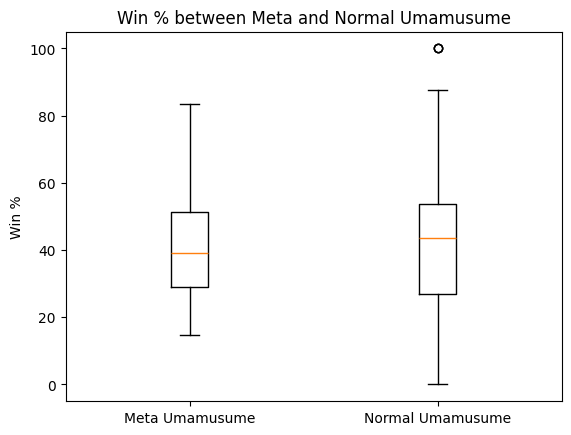

In [ ]:
plt.boxplot([growth_win_pct['win_percent'], no_growth_win_pct['win_percent']], tick_labels=['Meta Umamusume', 'Normal Umamusume'])
plt.ylabel('Win %')
plt.title('Win % between Meta and Normal Umamusume')
plt.show()

Contrary to expectation, the Normal Umamusume group has a higher mean and median win rate than the Meta Umamusume group, though the difference is quite small. The group also has more spread, which can be attributed as a byproduct of its larger sample size. In addition the three horses with a perfect race record (100% win rate) do not have Meta umamusume counterparts, and instead make up an outlier group in the Normal Umamusume distribution. Overall, this plot does not show evidence of a correlation between racehorse win rate and the metric of in-game strength used in this analysis, the presence of speed and power growth attributes.

### 5. Conclusions

Overall, the analysis of Umamusume character data in conjunction to data of racehorses of the same name has gleaned insight into the selection process of horses chosen to be represented in Umamusume, and investigated some possible correlations between the two datasets. The histogram of foaled dates shows that there may be some bias towards eras with more popular horses, but overall an effort is made to represent horses from a variety of eras, and to include multiple horses from each era to tell their story properly. The analysis into the distribution of training centers, while likely irrelevant to the racehorse selection process, revealed evidence of a correlation between training center and success for racehorses.

In regards to determining correlation between variables in the Umamusume and netkeiba datasets, the results are mixed. The scatter plot between racehorse weight and Umamusume character height showed a degree of positive correlation, however it is important to note that there are multiple outliers in the dataset that may have skewed the general trend of the full dataset. The inquiry into Meta umamusume and win rate was wholly inconclusive, showing that the allocation of in-game attributes such as growth rates most likely do not take win rate into account. It is important to note for this particular inquiry that both variables used are very arbitrary metrics for racehorse strength and Umamusume character strength. In general it is very hard to quantify the "strength" of a racehorse, as there is no formal rating system or measure of skill. A possible future step in this analysis would be to explore other alternative metrics of strength for both racehorses and Umamusume characters, such as number of G1 (highest grade of horse race) wins. For a better metric of Umamusume character strength, a more objective measurement such as usage rate could be utilized, though the gathering of such data would have to be manual and is out of the scope of this project. 

On a final note, in the broad scope of data science the sample size of Umamusume characters is fairly small at only 126 entries. If Umamusume: Pretty Derby is still in service for another 5 years, it would be interesting to rerun this analysis on the increased sample size, and see if there are any notable changes or new patterns.